<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro13cnn/cnn14tl_catdog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **tf dataset의 cat/dog 이미지 분류 + 전이학습 + 미세조정**
-  결과 보다는 과정을 이해하기!
- Base Model(BackBone) : MobileNet V2 사용

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

# tfds.disable_progress_bar() # 진행률 표시바 비활성화
(raw_train, raw_validation, raw_test), metadata = tfds.load(
    'cats_vs_dogs', # train밖에 없는 데이터이므로
    # 3개로 나눠 읽는데 8:1:1로 나눠서 읽어오겠다.
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised = True # dict타입으로 반환하겠다 , 안써주면 tuple
)
print(raw_train)
print(raw_validation)
print(raw_test)
print(metadata)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.0NQWAC_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    f

In [ ]:
total = metadata.splits['train'].num_examples
print('train 수 :',total)
print('raw train 수 :',int(total * 0.8))
print('raw val 수 :',int(total * 0.1))
print('raw test 수 :',int(total * 0.1))

train 수 : 23262
raw train 수 : 18609
raw val 수 : 2326
raw test 수 : 2326


cat
dog
원본 1개 : (216, 182, 3) 0


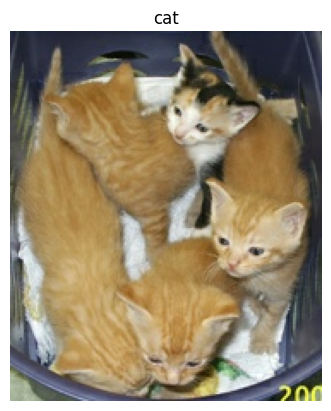

In [ ]:
# label명 얻기
get_label_name = metadata.features['label'].int2str
print(get_label_name(0))
print(get_label_name(1))

# sample자료 보기
for image, label in raw_train.skip(6).take(1):
  print(f'원본 {1}개 :', image.shape, label.numpy())
  plt.figure()
  plt.imshow(image)
  plt.title(get_label_name(label))
  plt.axis('off')
  plt.show()

In [ ]:
# 전처리 함수 생성하기
# cat /dog 이미지 크기가 다양함. -> 크기 고정하기
# 정규화
IMG_SIZE = 160

def format_exampleFunc(image, label):
  # 형변환(cast연산) : uint -> float32
  image = tf.cast(image, tf.float32)

  # 스케일링
  # 255/2 = 127.5 : 0~255 -> -1 ~ 1 사이로 스케일링
  image = (image/(255/2)) - 1

  # 이미지 resize
  image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
  return image, label

# 원본 데이터셋을 전처리된 데이터셋으로 변경
train = raw_train.map(                            # 함수 실행
              format_exampleFunc,
              # AUTOTUNE : 여러개의 sample을 병렬로 자동 처리(CPU 코어 수, 리소스 자원 관리 등), GPU의 유휴시간을 최소화 함.
              num_parallel_calls=tf.data.AUTOTUNE
)
validation = raw_validation.map(format_exampleFunc, num_parallel_calls=tf.data.AUTOTUNE)
test = raw_test.map(format_exampleFunc, num_parallel_calls=tf.data.AUTOTUNE)

# 전처리 검증
for img, label in train.take(1):
  print(f'전처리 샘플 dtype:', img.dtype)
  print(f'전처리 샘플 shape:', img.shape)
  print(f'Min / Max:', float(tf.reduce_min(img)),float(tf.reduce_max(img)))

# Batch Pipline 운영
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 1000

# train만 Shuffle진행 - 1000개의 sample을 메모리에 로딩해서 섞음.
# prefetch : 모델이 학습하는 동안 다음학습에 필요한 데이터를 미리 가져와 전처리해 둠.
# validataion, test는 고정.
train_batchs = train.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
validation_batchs = validation.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_batchs = test.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 배치 전 참고
for image_single, label_single in raw_train.take(2):
  print('원본 단일 이미지 shape:',image_single.numpy().shape)
  print('원본 라벨 :', label_single.numpy())

# 배치 후 참고
for image_batch, label_batch in train_batchs.take(2):
  print('전처리 배치 이미지 shape:',image_batch.numpy().shape)
  print('전처리 배치 라벨 :', label_batch.numpy())


전처리 샘플 dtype: <dtype: 'float32'>
전처리 샘플 shape: (160, 160, 3)
Min / Max: -1.0 1.0
원본 단일 이미지 shape: (262, 350, 3)
원본 라벨 : 1
원본 단일 이미지 shape: (409, 336, 3)
원본 라벨 : 1
전처리 배치 이미지 shape: (32, 160, 160, 3)
전처리 배치 라벨 : [0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 1 1 0 1 1 1 0 0 0 1 1 0]
전처리 배치 이미지 shape: (32, 160, 160, 3)
전처리 배치 라벨 : [1 0 0 1 0 1 0 0 0 1 0 1 1 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0 1 1 1 0]


In [ ]:
# Base Model : 전이 학습
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
# 이미지 특징을 뽑는 층만 사용하고 분류부분은 떼겠다. -> 현재 데이터는 cat / dog 을 분류하는 데이터이므로.
base_model = tf.keras.applications.MobileNetV2(
                                  input_shape=IMG_SHAPE,  # 입력 이미지 크기
                                  include_top=False,      # 분류기(Dense층) False
                                  weights='imagenet'
)
# print(base_model.summary())
#  Total params: 2,257,984 (8.61 MB)
#  Trainable params: 2,223,872 (8.48 MB)
#  Non-trainable params: 34,112 (133.25 KB) -> 분류기 부분이 빠짐.

# 전처리 / 배치가 된 tensor를 통과시켜 특징 맵 얻기
images_batch, labels_batch = next(iter(train_batchs))
fearture_batch = base_model(images_batch)
print('입력 배치 shape', images_batch.shape)  # 입력 배치 shape (32, 160, 160, 3)
# 특징맵 shape (32, 5, 5, 1280)
# - 하나의 이미지는 (5, 5, 1280)짜리 특징맵으로 표현됨.(5X5의 특징맵 1280개 가 만들어짐)
print('특징맵 shape', fearture_batch.shape)

gloval_avg = tf.keras.layers.GlobalAveragePooling2D()(fearture_batch)
print('GAP(GlobalAveragePooling) 후 :', gloval_avg.shape) # (32, 1280) - 5*5를 평균내고 1280차 벡터 하나로 요약
# GAP = 배치 크기는 유지하면서 최종 shape(32, 1280)을 축만 남기면 나중에 이미지당 한개의 고정길이 벡터를 얻어 Dense(분류기)에 넣기 쉬워진다.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
입력 배치 shape (32, 160, 160, 3)
특징맵 shape (32, 5, 5, 1280)
GAP(GlobalAveragePooling) 후 : (32, 1280)


Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 102s 143ms/step - accuracy: 0.9735 - loss: 0.0786 - val_accuracy: 0.9807 - val_loss: 0.0480
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 37s 57ms/step - accuracy: 0.9846 - loss: 0.0444 - val_accuracy: 0.9819 - val_loss: 0.0476
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 43s 63ms/step - accuracy: 0.9866 - loss: 0.0391 - val_accuracy: 0.9815 - val_loss: 0.0443
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9874 - loss: 0.0356 - val_accuracy: 0.9824 - val_loss: 0.0435
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 36s 59ms/step - accuracy: 0.9884 - loss: 0.0334 - val_accuracy: 0.9828 - val_loss: 0.0441
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.9895 - loss: 0.0305 - val_accuracy: 0.9802 - val_loss: 0.0525
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 36s 59ms/step - accuracy: 0.9903 - loss: 0.0291 - val_accuracy: 0.9841 - val_loss: 0.0433
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.9911 - loss: 0.0276 

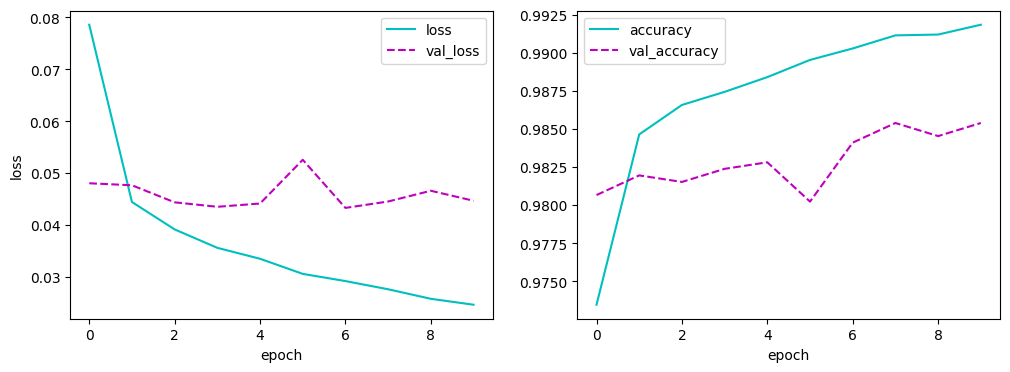

In [ ]:
# 모델 정의하기
# 1) Sequential로 정의 (base_model + 이진분류기)
# model = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=IMG_SHAPE),
#     base_model, # Conv, Pooling Layer
#     tf.keras.layers.GlobalAveragePooling2D(),
#     tf.keras.layers.Dense(units=1, activation='sigmoid') # 이진 분류기
# ])

# 2) Function API로 정의 (base_model + 이진분류기)
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False) # base model의 conv, pooling는 학습에서 제외
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(units=1, activation='sigmoid')(x)
model = tf.keras.Model(inputs, outputs)
# print(model.summary())
#  Total params: 2,259,265 (8.62 MB)
#  Trainable params: 2,225,153 (8.49 MB)
#  Non-trainable params: 34,112 (133.25 KB) -> base model(backborn)의 분류기는 참여하지 않음

base_model.trainable = False # 특징 추출기(Conv, Pooling) 학습 참여 동결
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
history = model.fit(
    train_batchs,
    validation_data=validation_batchs,
    epochs=10
)

# 평가
loss, acc = model.evaluate(test_batchs, verbose=0)
print(f'검증 평가 결과 \ntest_loss : {loss:.4f} test_acc :{acc:.4f}')

# 학습 곡선 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'c-', label='loss')
plt.plot(history.history['val_loss'], 'm--', label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'c-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'm--', label='val_accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [ ]:
# Fine Tunning : 미세조정 적용하기
base_model.trainable = True # 특징 추출기(Conv, Pooling) 학습 참여 동결해제
fine_tune_at = 100  # MobileNetV2레이어 약150개 중 50개만 학습에 참여(분석가 마음대로 조정함)

for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# callback = Checkpoint, EarlyStopping
os.makedirs('checkpoints', exist_ok=True)
ckpt_path_ft = "checkpoints/finetune_best.keras"
callbacks_ft = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=ckpt_path_ft,
        monitor='val_accurcay',
        mode='max',
        save_best_only=True,
        verbose=0
    ),
    # LR(learning_rate)에 관련됨 : val_loss 개선이 멈추면 learning_rate를 0.5배 줄임
    tf.keras.callbacks.ReduceLROnPlateau(
        moniter='val_loss',
        factor=0.5,
        patience=3,
        verbose=0
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=0
    )
]


In [ ]:
EPOCHS_TRANSFER = 10 # 전이학습에서 이미 10번 학습함
EPOCHS_FINETUNE = 10 # 미세조정에서 추가 학습할 epoch 수

history_ft = model.fit(
    train_batchs,
    validation_data=validation_batchs,
    epochs=EPOCHS_TRANSFER + EPOCHS_FINETUNE,
    initial_epoch=EPOCHS_TRANSFER, # 전이 학습 이후 10번만 Fine Tunning 함.
    callbacks=callbacks_ft,
    verbose=2
)

# 평가
loss, acc = model.evaluate(test_batchs, verbose=0)
print(f'검증 평가 결과 \ntest_loss : {loss:.4f} test_acc :{acc:.4f}')

Epoch 11/20


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accurcay available.
  if self._should_save_model(epoch, batch, logs, filepath):


582/582 - 77s - 132ms/step - accuracy: 0.8808 - loss: 0.3162 - val_accuracy: 0.9678 - val_loss: 0.0925 - learning_rate: 1.0000e-06
Epoch 12/20
582/582 - 52s - 90ms/step - accuracy: 0.9330 - loss: 0.1702 - val_accuracy: 0.9570 - val_loss: 0.1137 - learning_rate: 1.0000e-06
Epoch 13/20
582/582 - 37s - 63ms/step - accuracy: 0.9485 - loss: 0.1251 - val_accuracy: 0.9604 - val_loss: 0.1087 - learning_rate: 1.0000e-06
Epoch 14/20
582/582 - 36s - 62ms/step - accuracy: 0.9586 - loss: 0.1087 - val_accuracy: 0.9635 - val_loss: 0.1020 - learning_rate: 1.0000e-06
Epoch 15/20
582/582 - 37s - 63ms/step - accuracy: 0.9608 - loss: 0.0988 - val_accuracy: 0.9630 - val_loss: 0.0994 - learning_rate: 5.0000e-07
Epoch 16/20
582/582 - 37s - 64ms/step - accuracy: 0.9627 - loss: 0.0987 - val_accuracy: 0.9639 - val_loss: 0.0975 - learning_rate: 5.0000e-07
검증 평가 결과 
test_loss : 0.0932 test_acc :0.9656


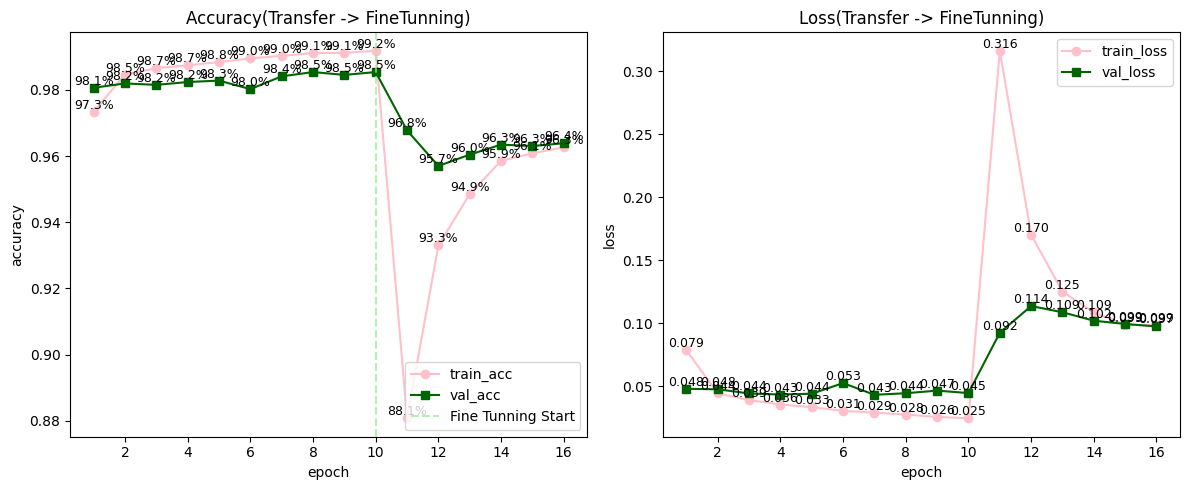

In [ ]:
# 전이학습 + 미세조정 학습 곡선 비교 시각화 - 시각화를 통한 테스트 성능비교
def concat_hist(h1, h2):
  keys = h1.history.keys()
  out = {}
  for k in keys:
    out[k] =h1.history[k] + h2.history[k] # 각 key(loss, acc)에 대해 리스트에 이어붙임.
  return out


hist_all = concat_hist(history, history_ft)
acc = hist_all['accuracy']
val_acc = hist_all['val_accuracy']
loss = hist_all['loss']
val_loss = hist_all['val_loss']

epochs = range(1, len(acc) + 1)
spilt_epoch = EPOCHS_TRANSFER  # 전이학습과 미세조정 경계선 위치

plt.figure(figsize=(12, 5))

# acc
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'o-', label='train_acc', color='pink')
plt.plot(epochs, val_acc, 's-', label='val_acc', color='darkgreen')

for i, v in enumerate(acc):
  plt.text(epochs[i], v, f'{v * 100:.1f}%', ha='center', va='bottom', fontsize=9)

for i, v in enumerate(val_acc):
  plt.text(epochs[i], v, f'{v * 100:.1f}%', ha='center', va='bottom', fontsize=9)

# 전이 -> 미세조정 전환선 긋기
plt.axvline(spilt_epoch, linestyle='--', alpha=0.7, label='Fine Tunning Start', c='lightgreen')
plt.title('Accuracy(Transfer -> FineTunning)')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(loc='lower right')

# loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'o-', label='train_loss', color='pink')
plt.plot(epochs, val_loss, 's-', label='val_loss', color='darkgreen')

for i, v in enumerate(loss):
  plt.text(epochs[i], v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

for i, v in enumerate(val_loss):
  plt.text(epochs[i], v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.title('Loss(Transfer -> FineTunning)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()
